# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ari Dwi Prasetyo
- Email: aridwip15@gmail.com
- Id Dicoding: aridwip

## Persiapan

### Menyiapkan library yang dibutuhkan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

### Menyiapkan data yang akan digunakan

In [4]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [5]:
# Load dataset (semicolon-separated)
df = pd.read_csv('data.csv', sep=';')

print('5 data teratas:')
print(df.head())
print('\nUkuran data:', df.shape)

5 data teratas:
   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         122.0            1                     19   
1                         160.0            1                      1   
2                         122.0

In [6]:
# Cek struktur data
print('Info data:')
df.info()

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 n

## Data Understanding

### Statistik Deskriptif

In [7]:
print(df.describe())

       Marital_status  Application_mode  Application_order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime_evening_attendance  Previous_qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000                1.000000   
25%                

**Insight**: Dataset memiliki 4.424 baris dan 37 kolom. Fitur mencakup data demografis mahasiswa, riwayat akademik semester 1 & 2, serta kondisi makroekonomi.

### Pemeriksaan Missing Value

In [8]:
print('Jumlah missing values per kolom:')
missing = df.isnull().sum()
print(missing[missing >= 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Jumlah missing values per kolom:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment

**Insight**: Dataset tidak memiliki missing value sehingga tidak diperlukan imputasi khusus pada tahap ini.

### Distribusi Target (Status)

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dropout rate: 32.12%


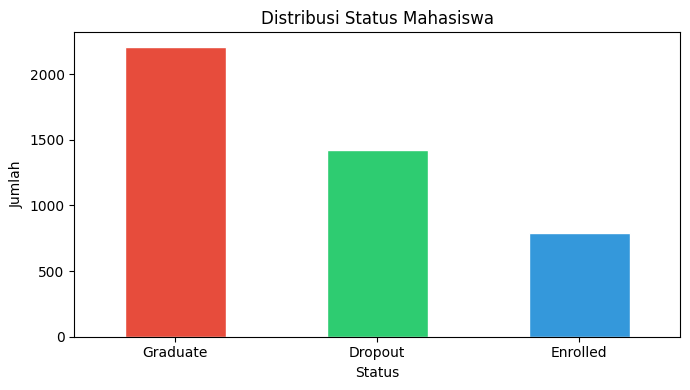

In [9]:
print('Distribusi Status:')
print(df['Status'].value_counts())
print(f'\nDropout rate: {(df["Status"]=="Dropout").mean()*100:.2f}%')

plt.figure(figsize=(7, 4))
colors = ['#e74c3c', '#2ecc71', '#3498db']
df['Status'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight**: Terdapat 3 kelas target — Graduate (49.9%), Dropout (32.1%), dan Enrolled (17.9%). Dataset tidak seimbang, sehingga digunakan `class_weight='balanced'` pada model.

## Exploratory Data Analysis (EDA)

EDA dilakukan secara menyeluruh **sebelum preprocessing** untuk mendapatkan insight dari data mentah. Jenis EDA yang dilakukan:
- **EDA Univariate Numerikal**: Distribusi fitur numerik
- **EDA Univariate Kategorikal/Binary**: Distribusi fitur binary
- **Analisis Korelasi**: Heatmap korelasi antar fitur numerik
- **EDA Multivariate**: Hubungan fitur terhadap Status mahasiswa

Identifikasi Tipe Kolom

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
eda_num = [c for c in numerical_cols]

print(f'Kolom numerik ({len(eda_num)}): {eda_num}')
print(f'\nKolom kategorikal/target: {categorical_cols}')

Kolom numerik (36): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']

Kolom kategorikal/target: ['Stat

EDA Univariate — Fitur Numerikal Utama

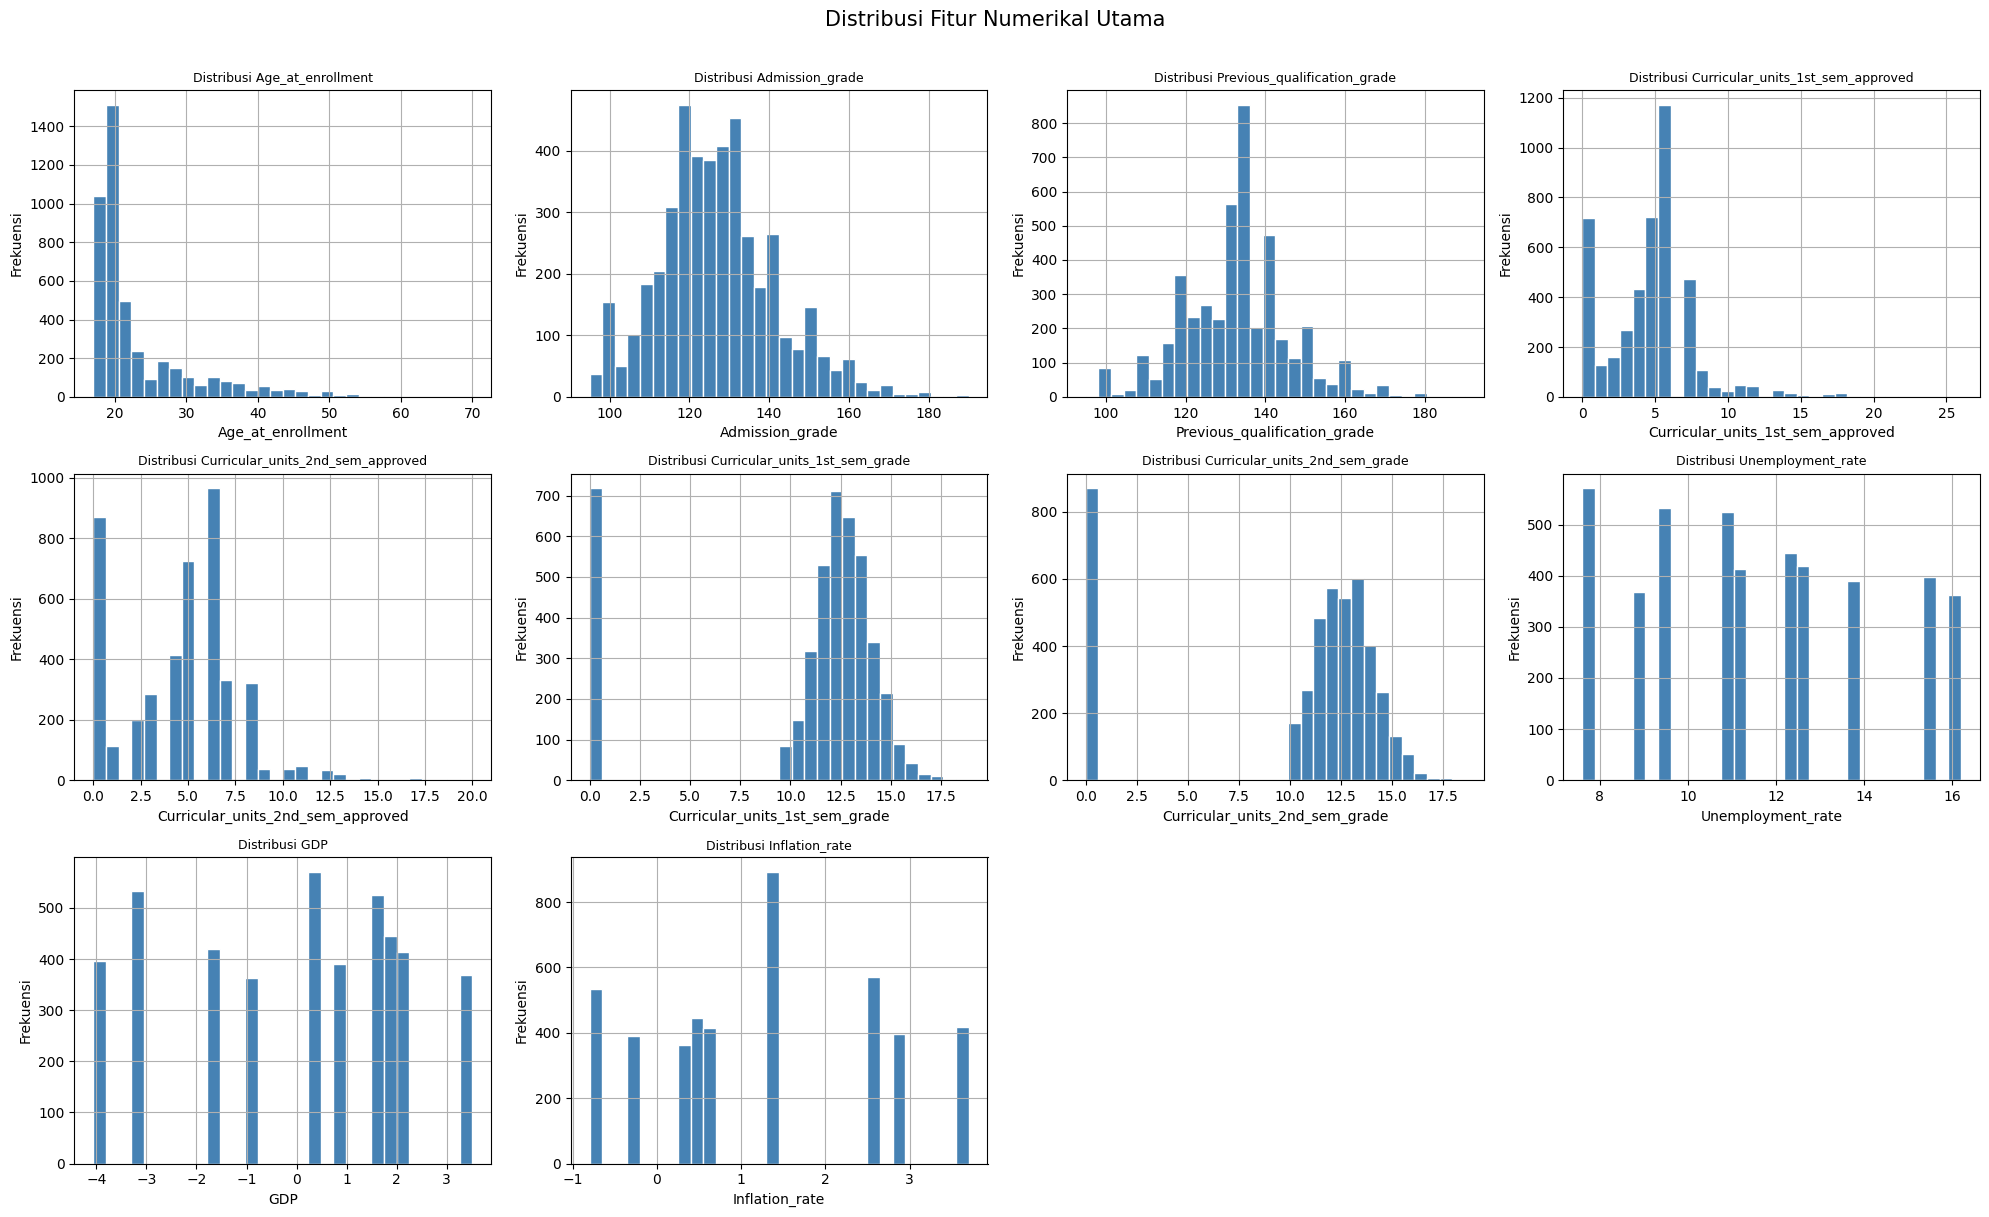

In [11]:
key_num_eda = ['Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
               'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
               'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
               'Unemployment_rate', 'GDP', 'Inflation_rate']
key_num_eda = [c for c in key_num_eda if c in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(key_num_eda) / n_cols))
plt.figure(figsize=(20, n_rows * 4))
for i, col in enumerate(key_num_eda):
    plt.subplot(n_rows, n_cols, i + 1)
    df[col].hist(bins=30, color='steelblue', edgecolor='white')
    plt.title(f'Distribusi {col}', fontsize=9)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.suptitle('Distribusi Fitur Numerikal Utama', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Insight**:
- `Age_at_enrollment` sebagian besar mahasiswa berusia 17–25 tahun, dengan distribusi right-skewed.
- `Admission_grade` dan `Previous_qualification_grade` mendekati distribusi normal.
- Banyak mahasiswa memiliki nilai `Curricular_units_approved` = 0, menunjukkan ada mahasiswa yang tidak lulus satupun unit.

EDA Univariate — Fitur Binary / Kategorikal

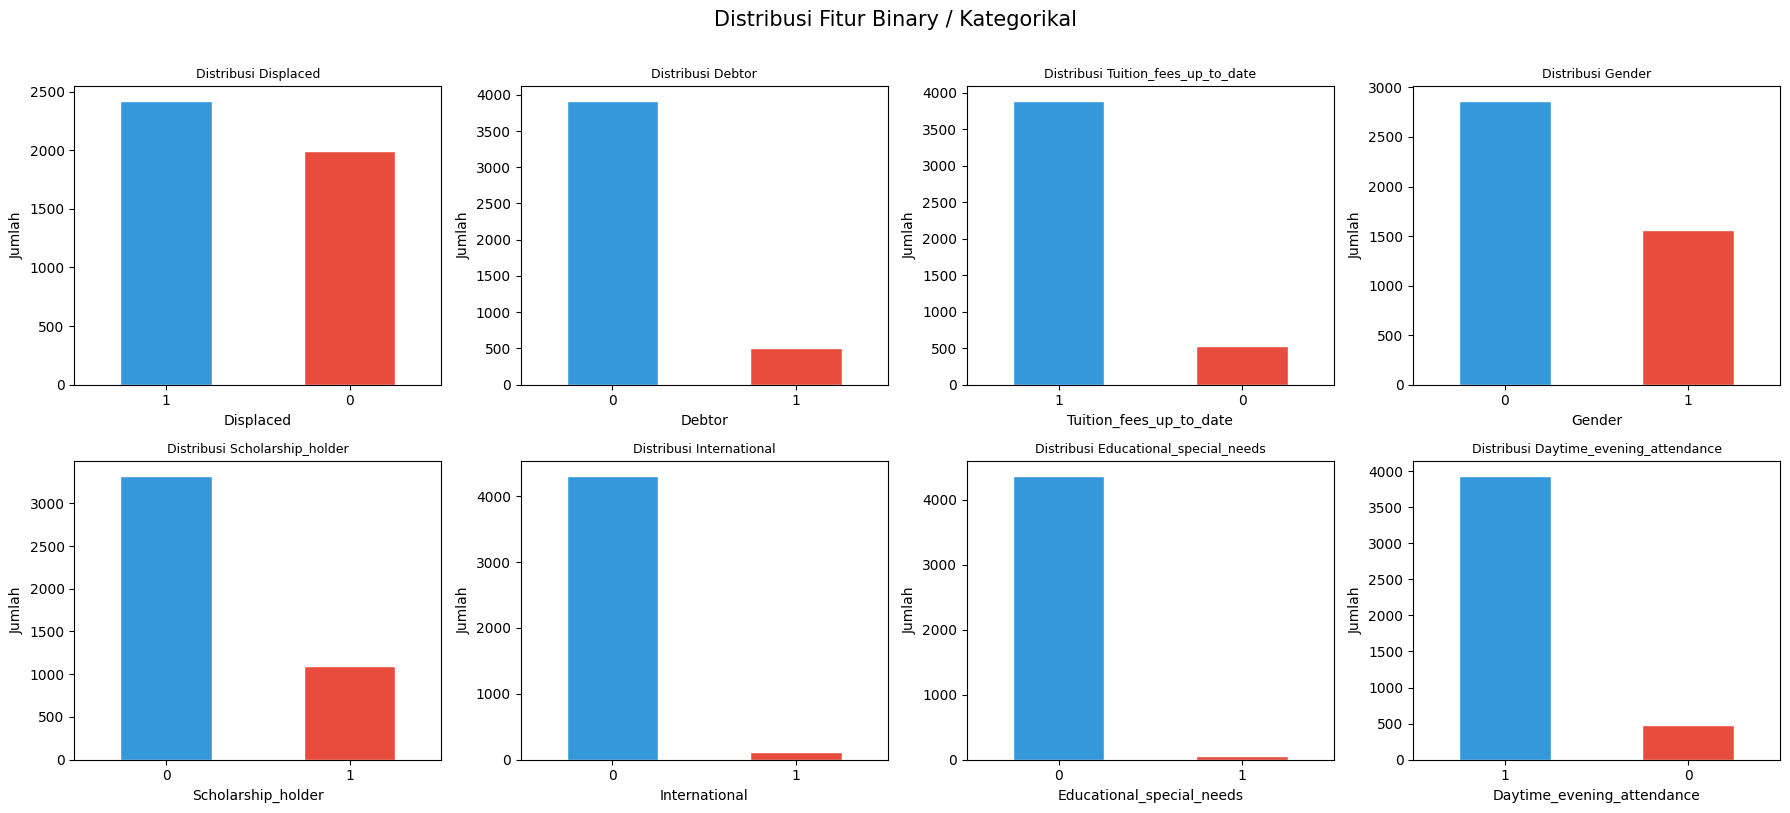

In [12]:
binary_cols = ['Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender',
               'Scholarship_holder', 'International', 'Educational_special_needs',
               'Daytime_evening_attendance']
binary_cols = [c for c in binary_cols if c in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(binary_cols) / n_cols))
plt.figure(figsize=(18, n_rows * 4))
for i, col in enumerate(binary_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    df[col].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='white', ax=plt.gca())
    plt.title(f'Distribusi {col}', fontsize=9)
    plt.xlabel(col)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=0)
plt.suptitle('Distribusi Fitur Binary / Kategorikal', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Insight**:
- Sebagian besar mahasiswa membayar uang kuliah tepat waktu (`Tuition_fees_up_to_date=1`).
- Mayoritas mahasiswa bukan pemegang beasiswa (`Scholarship_holder=0`).
- Lebih banyak mahasiswa laki-laki (`Gender=1`) dibanding perempuan.
- Sebagian kecil mahasiswa memiliki status Debtor (tunggakan pembayaran).

Analisis Korelasi Fitur Numerikal

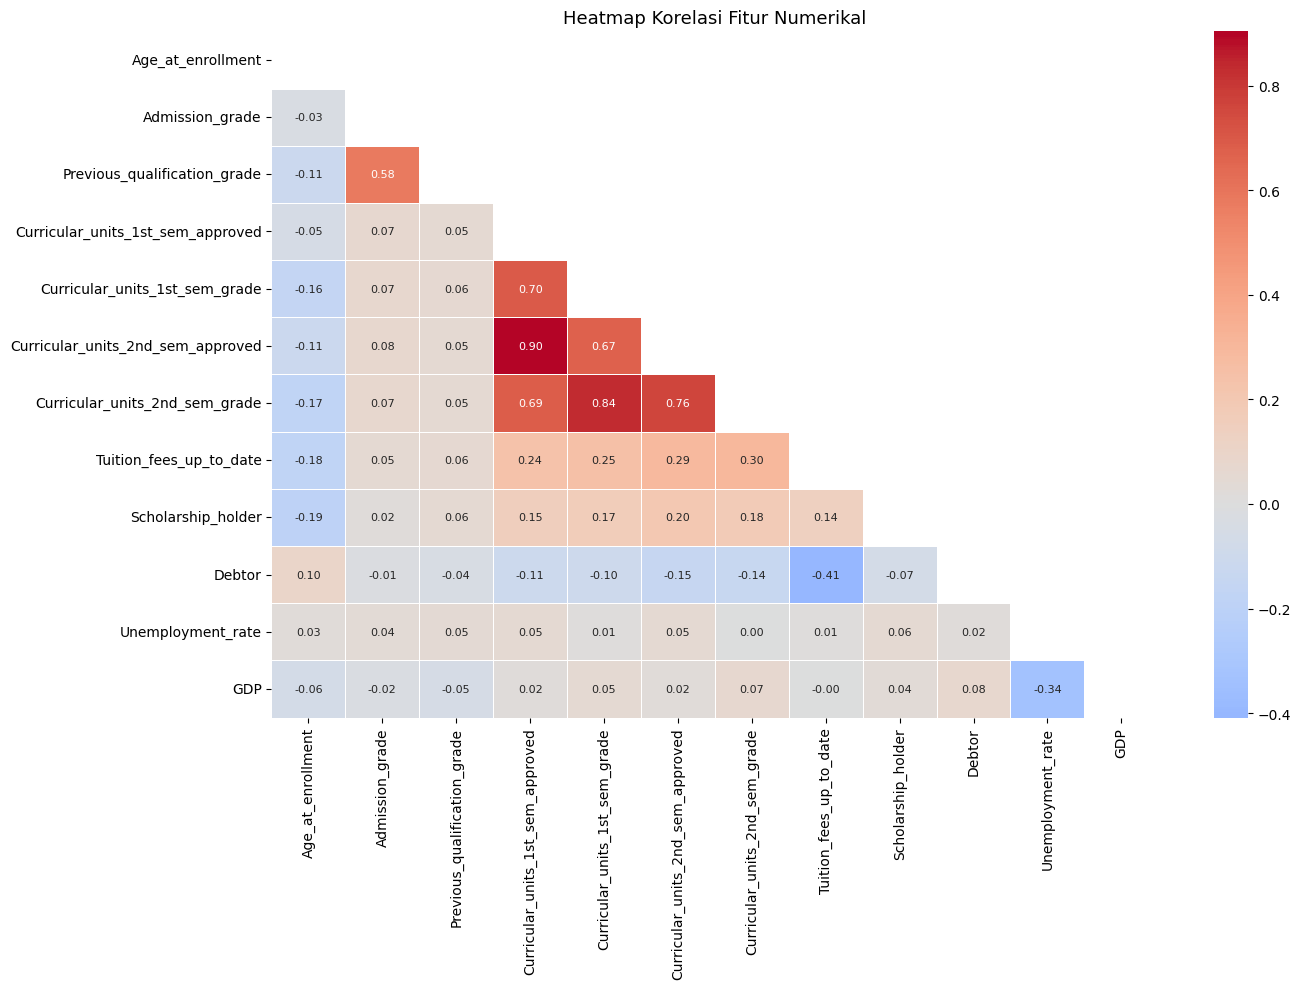

In [13]:
corr_cols = ['Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
             'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
             'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
             'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor',
             'Unemployment_rate', 'GDP']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Fitur Numerikal', fontsize=13)
plt.tight_layout()
plt.show()

**Insight**:
- `Curricular_units_1st_sem_approved` dan `Curricular_units_2nd_sem_approved` berkorelasi sangat tinggi — mahasiswa yang lulus banyak unit di semester 1 cenderung juga lulus banyak di semester 2.
- Nilai semester 1 dan 2 (`grade`) juga berkorelasi kuat satu sama lain.
- `Debtor` berkorelasi negatif dengan `Tuition_fees_up_to_date`.

EDA Multivariate — Fitur Numerik vs Status

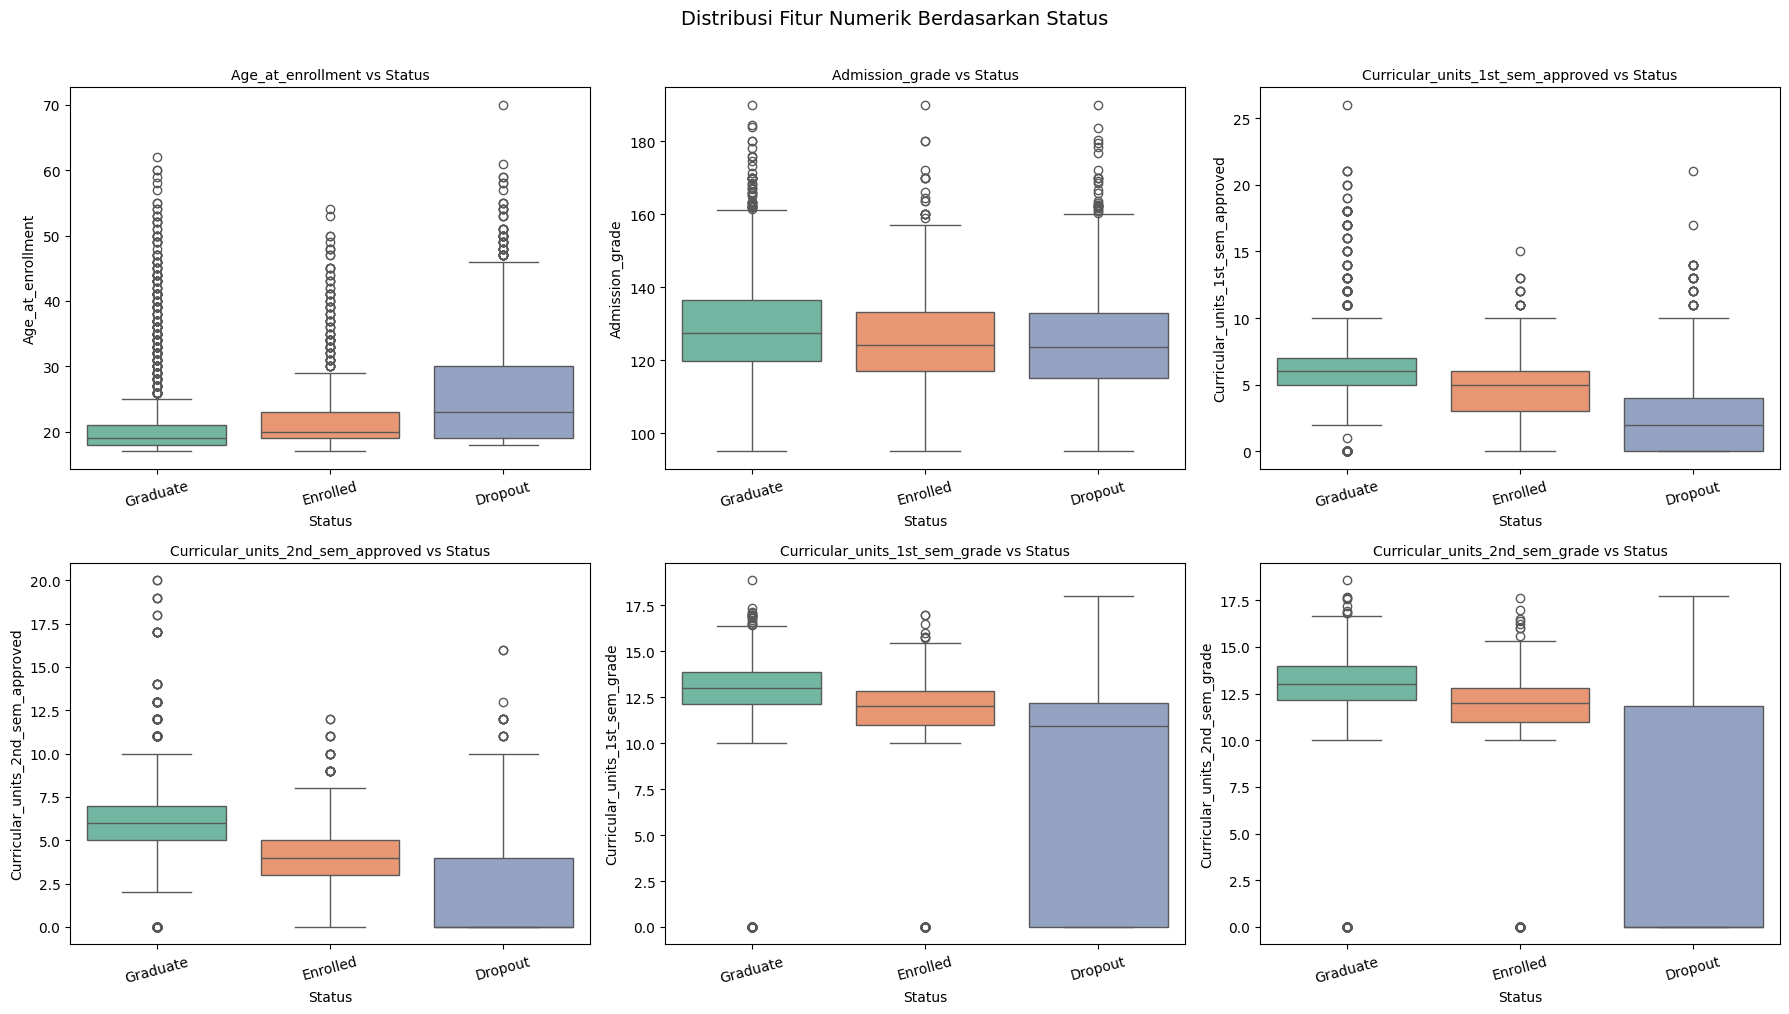

In [14]:
key_box = ['Age_at_enrollment', 'Admission_grade', 'Curricular_units_1st_sem_approved',
           'Curricular_units_2nd_sem_approved', 'Curricular_units_1st_sem_grade',
           'Curricular_units_2nd_sem_grade']
key_box = [c for c in key_box if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_box) / n_cols))
plt.figure(figsize=(18, n_rows * 5))
for i, col in enumerate(key_box):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, x='Status', y=col, palette='Set2',
                order=['Graduate', 'Enrolled', 'Dropout'])
    plt.title(f'{col} vs Status', fontsize=10)
    plt.xticks(rotation=15)
plt.suptitle('Distribusi Fitur Numerik Berdasarkan Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insight**:
- **Mahasiswa Graduate** memiliki rata-rata `Curricular_units_approved` dan `grade` jauh lebih tinggi.
- **Mahasiswa Dropout** memiliki nilai dan jumlah unit yang lulus sangat rendah, bahkan mendekati 0.
- `Age_at_enrollment` menunjukkan mahasiswa Dropout cenderung berusia lebih tua saat mendaftar.

EDA Multivariate — Fitur Binary vs Status

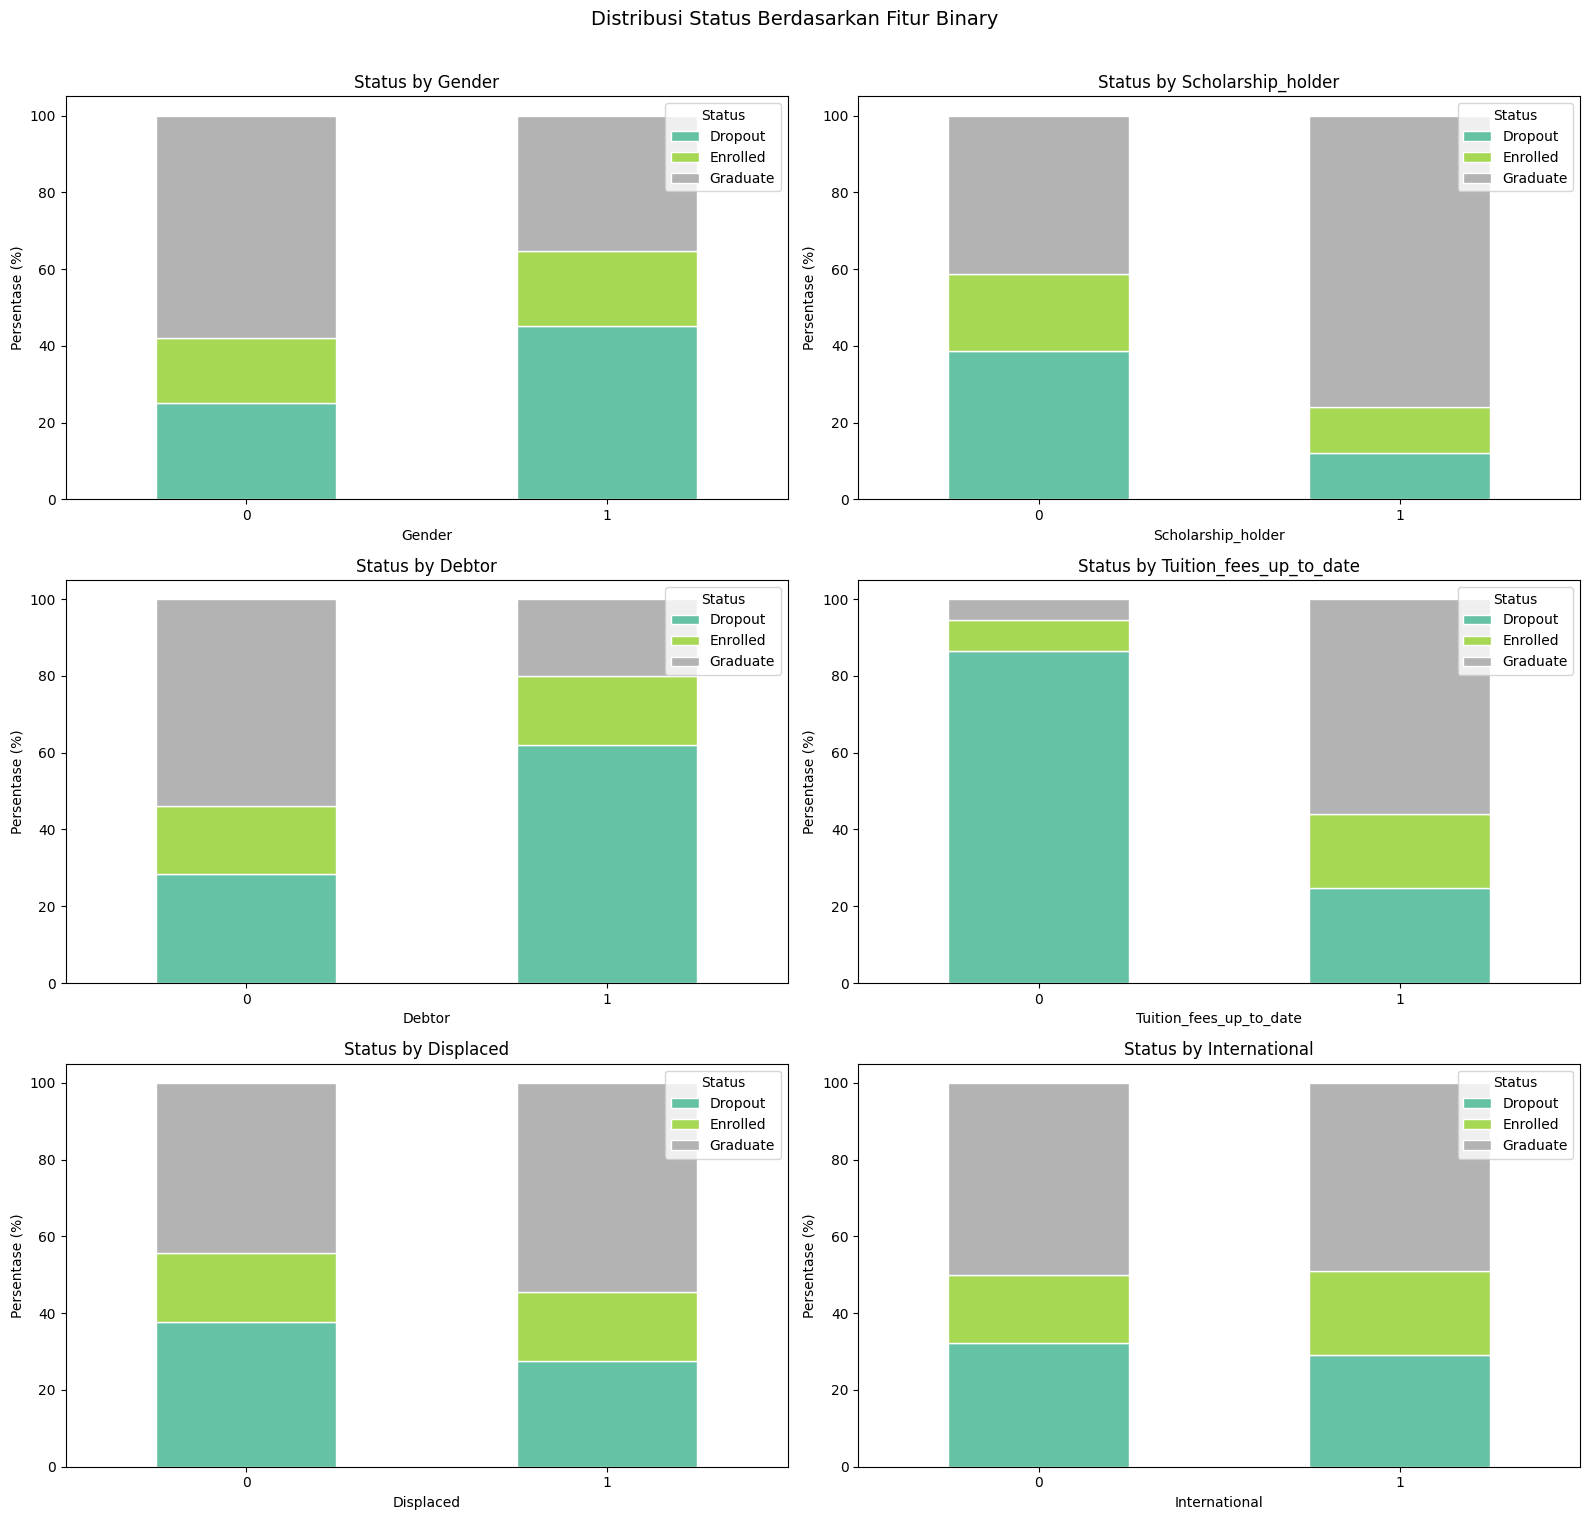

In [15]:
binary_vs = ['Gender', 'Scholarship_holder', 'Debtor',
             'Tuition_fees_up_to_date', 'Displaced', 'International']
binary_vs = [c for c in binary_vs if c in df.columns]

n_cols = 2
n_rows = int(np.ceil(len(binary_vs) / n_cols))
plt.figure(figsize=(16, n_rows * 5))
for i, col in enumerate(binary_vs):
    plt.subplot(n_rows, n_cols, i + 1)
    ct = df.groupby([col, 'Status']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set2', edgecolor='white')
    plt.title(f'Status by {col}')
    plt.xlabel(col)
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Status', loc='upper right')
plt.suptitle('Distribusi Status Berdasarkan Fitur Binary', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insight**:
- **Tuition_fees_up_to_date=1**: mahasiswa yang membayar tepat waktu hampir semua Graduate.
- **Debtor=1**: mahasiswa penunggak memiliki dropout rate jauh lebih tinggi.
- **Scholarship_holder=1**: pemegang beasiswa memiliki tingkat kelulusan lebih tinggi.

Dropout Rate berdasarkan Tuition dan Scholarship

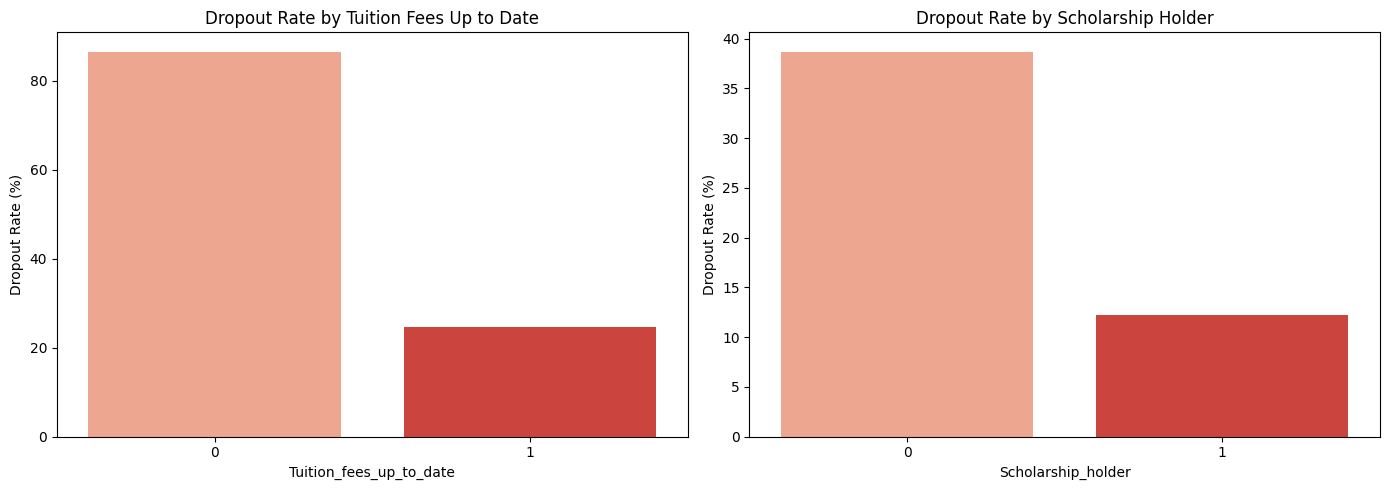

In [16]:
fig_, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['Tuition_fees_up_to_date', 'Scholarship_holder'],
                           ['Tuition Fees Up to Date', 'Scholarship Holder']):
    dr = df.groupby(col)['Status'].apply(lambda x: (x == 'Dropout').mean() * 100).reset_index()
    dr.columns = [col, 'Dropout_Rate']
    sns.barplot(data=dr, x=col, y='Dropout_Rate', palette='Reds', ax=ax)
    ax.set_title(f'Dropout Rate by {title}')
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

**Insight**:
- Mahasiswa yang **tidak membayar uang kuliah tepat waktu** memiliki dropout rate >80%.
- Pemegang beasiswa (`Scholarship_holder=1`) memiliki dropout rate lebih rendah.

Distribusi Usia Pendaftaran per Status (KDE)

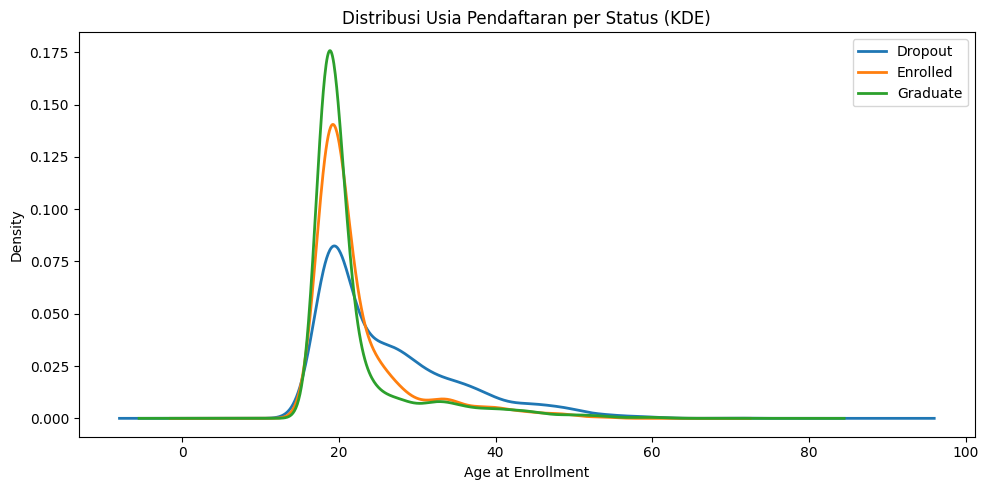

In [17]:
plt.figure(figsize=(10, 5))
for status, grp in df.groupby('Status'):
    grp['Age_at_enrollment'].plot(kind='kde', label=status, linewidth=2)
plt.title('Distribusi Usia Pendaftaran per Status (KDE)')
plt.xlabel('Age at Enrollment')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

**Insight**: Mahasiswa Dropout cenderung berusia lebih tua saat mendaftar. Mahasiswa Graduate terkonsentrasi pada usia muda (17–20 tahun).

Performa Akademik per Status

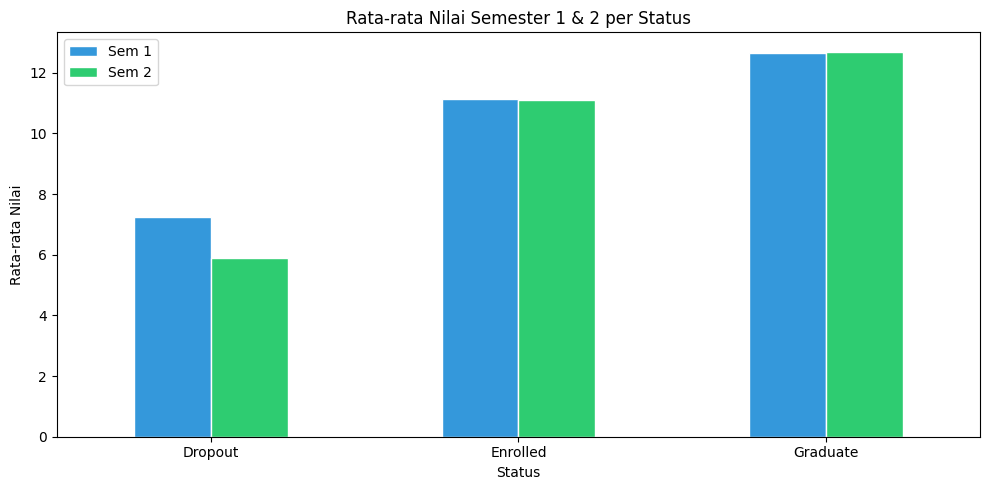

In [18]:
plt.figure(figsize=(10, 5))
df_acad = df.groupby('Status')[['Curricular_units_1st_sem_grade',
                                   'Curricular_units_2nd_sem_grade']].mean()
df_acad.plot(kind='bar', color=['#3498db', '#2ecc71'], edgecolor='white', ax=plt.gca())
plt.title('Rata-rata Nilai Semester 1 & 2 per Status')
plt.xlabel('Status')
plt.ylabel('Rata-rata Nilai')
plt.xticks(rotation=0)
plt.legend(['Sem 1', 'Sem 2'])
plt.tight_layout()
plt.show()

**Insight**: Graduate memiliki rata-rata nilai semester 1 dan 2 tertinggi. Dropout memiliki rata-rata nilai terendah, bahkan mendekati 0 — kemungkinan besar tidak mengikuti ujian.

Unemployment Rate per Status

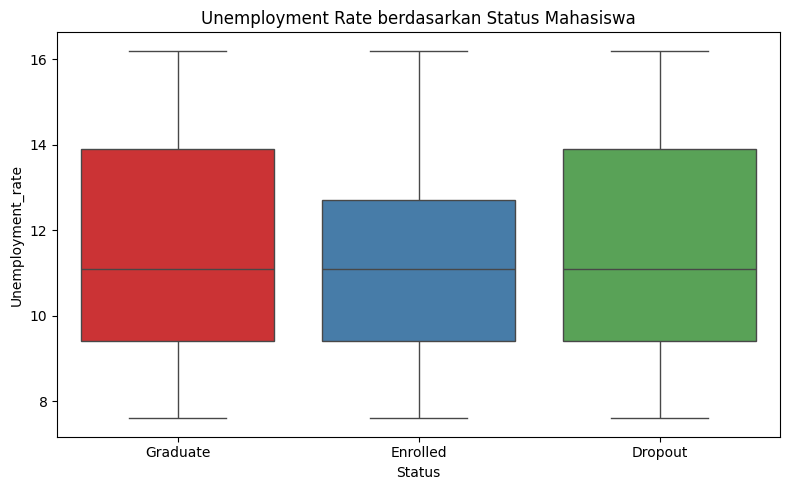

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Status', y='Unemployment_rate', palette='Set1',
            order=['Graduate', 'Enrolled', 'Dropout'])
plt.title('Unemployment Rate berdasarkan Status Mahasiswa')
plt.tight_layout()
plt.show()

**Insight**: Kondisi ekonomi (unemployment rate) memiliki sedikit perbedaan antar kelompok, namun bukan faktor dominan dibanding performa akademik.

Ringkasan Temuan EDA

| Faktor | Temuan |
|---|---|
| **Tuition_fees_up_to_date** | Mahasiswa tidak bayar tepat waktu → dropout rate >80% |
| **Curricular_units_approved** | Jumlah unit lulus Sem 1 & 2 sangat rendah pada Dropout |
| **Nilai Semester 1 & 2** | Grade Dropout mendekati 0; Graduate memiliki grade tertinggi |
| **Debtor** | Penunggak memiliki dropout rate jauh lebih tinggi |
| **Scholarship_holder** | Pemegang beasiswa lebih sedikit yang dropout |
| **Age_at_enrollment** | Mahasiswa lebih tua cenderung lebih banyak dropout |
| **Admission_grade** | Graduate memiliki admission grade lebih tinggi |
| **Unemployment_rate** | Pengaruh kecil terhadap status, bukan faktor utama |

## Data Preparation / Preprocessing

### Label Encoding Target

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
print('Label encoding Status:')
print(dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding Status:
{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


**Insight**: Target `Status` di-encode menjadi integer: Dropout=0, Enrolled=1, Graduate=2.

### Memisahkan Fitur dan Target

In [21]:
X = df.drop(['Status', 'Status_encoded'], axis=1)
y = df['Status_encoded']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Fitur numerik ({len(numerical_features)}): {numerical_features}')
print(f'Fitur kategorikal ({len(categorical_features)}): {categorical_features}')

Fitur numerik (36): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']
Fitur kategorikal (0): []


### Pembagian Data (Train-Test Split)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('\nDistribusi y_train:')
print(pd.Series(y_train).value_counts())
print('\nDistribusi y_test:')
print(pd.Series(y_test).value_counts())

X_train: (3539, 36) | X_test: (885, 36)

Distribusi y_train:
Status_encoded
2    1767
0    1137
1     635
Name: count, dtype: int64

Distribusi y_test:
Status_encoded
2    442
0    284
1    159
Name: count, dtype: int64


**Insight**: Data dibagi 80% train / 20% test dengan `stratify=y` untuk menjaga proporsi kelas.

### Pipeline Preprocessing

In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Pipeline preprocessing berhasil dibuat.')

Pipeline preprocessing berhasil dibuat.


## Modeling

### Pemilihan Model
Model yang dipilih: **Random Forest Classifier**
- Robust untuk multiclass classification
- Tidak sensitif terhadap skala fitur
- Menghasilkan `feature_importances_` untuk interpretasi

### Pembangunan Model

In [24]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

print('Model pipeline berhasil dibangun.')
print(clf)

Model pipeline berhasil dibangun.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Marital_status',
                                                   'Application_mode',
                                                   'Application_order',
                                                   'Course',
                                                   'Daytime_evening_attendance',
                                                   'Previous_qualification',
                                                   'Previous_qualification_grade',
                 

### Pelatihan Model

In [25]:
clf.fit(X_train, y_train)
print('Model berhasil dilatih.')

Model berhasil dilatih.


## Evaluation

In [26]:
y_pred = clf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.768361581920904


In [27]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.57      0.36      0.44       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.75       885



Confusion Matrix:
 [[212  23  49]
 [ 36  58  65]
 [ 11  21 410]]


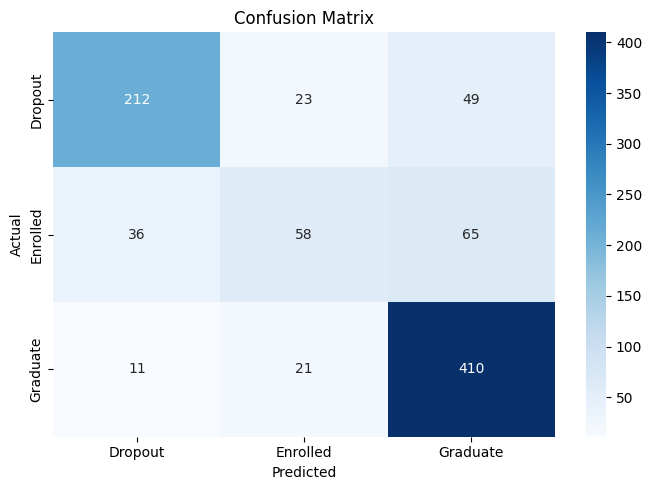

In [28]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Insight**:
- **Accuracy 76.8%** — model cukup baik untuk kasus 3-kelas.
- **Graduate** terprediksi paling akurat (recall 93%).
- **Enrolled** paling sulit dibedakan, kemungkinan bercampur dengan Graduate dan Dropout.
- **Dropout** precision 82%, sangat berguna untuk early warning system.

### Identifikasi Faktor yang Mempengaruhi Status

In [29]:
ohe = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat = ohe.get_feature_names_out(categorical_features) if categorical_features else []
all_feature_names = numerical_features + list(encoded_cat)

importances = clf.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print('=== TOP 15 FAKTOR ===')
print(feature_importance_df.head(15))

=== TOP 15 FAKTOR ===
                                 Feature  Importance
30     Curricular_units_2nd_sem_approved    0.126016
31        Curricular_units_2nd_sem_grade    0.093321
24     Curricular_units_1st_sem_approved    0.067409
25        Curricular_units_1st_sem_grade    0.065422
12                       Admission_grade    0.047419
29  Curricular_units_2nd_sem_evaluations    0.045668
19                     Age_at_enrollment    0.042926
6           Previous_qualification_grade    0.042507
23  Curricular_units_1st_sem_evaluations    0.041072
16               Tuition_fees_up_to_date    0.037364
3                                 Course    0.034524
11                    Fathers_occupation    0.033758
10                    Mothers_occupation    0.030101
35                                   GDP    0.026760
33                     Unemployment_rate    0.025555


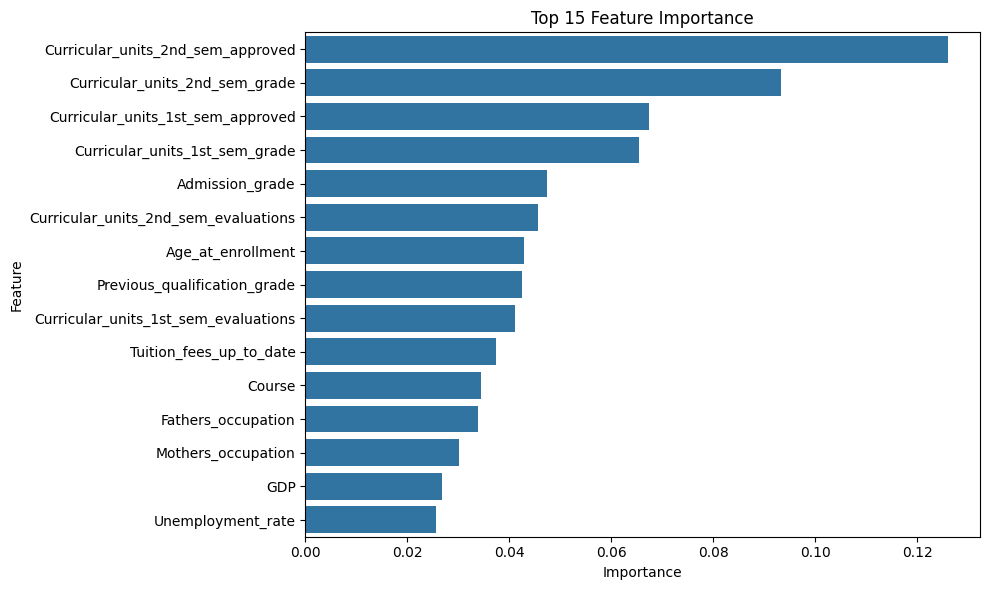

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

In [31]:
feature_importance_df.to_csv('feature_importance.csv', index=False)
print('Feature importance disimpan ke feature_importance.csv')

Feature importance disimpan ke feature_importance.csv


In [32]:
import joblib
joblib.dump(clf, 'model_student.pkl')
joblib.dump(le, 'label_encoder.pkl')
print('Model disimpan: model_student.pkl')

# Contoh prediksi
sample = X_test.iloc[[0]]
pred_label = le.inverse_transform(clf.predict(sample))[0]
pred_proba = clf.predict_proba(sample)[0]

print('\n=== CONTOH PREDIKSI ===')
print('Status Prediksi:', pred_label)
print('Probabilitas:', dict(zip(le.classes_, pred_proba.round(4))))

Model disimpan: model_student.pkl

=== CONTOH PREDIKSI ===
Status Prediksi: Graduate
Probabilitas: {'Dropout': np.float64(0.095), 'Enrolled': np.float64(0.02), 'Graduate': np.float64(0.885)}


In [1]:
!pip freeze > requirements.txt